# Regresion lineal multivariable polinomial

Este notebook compara modelos de grados `1`, `2`, `3` y `5` para predecir `mpg` usando todas las variables numericas del dataset `Auto MPG`, siguiendo la guia del taller.

## Objetivos

- Cargar y limpiar el dataset `Auto MPG`.
- Entrenar una regresion multivariable con expansion polinomial usando todas las variables numericas disponibles.
- Comparar metricas de `train` y `test` para detectar subajuste y sobreajuste.
- Reportar e interpretar `MAE`, `MSE`, `RMSE` y `R²`.
- Visualizar el rendimiento por grados y por umbrales de error absoluto.
- Ver como cambia la prediccion al variar cada variable, manteniendo fijas las demas.

In [15]:
from pathlib import Path
import sys
import importlib

import pandas as pd
from IPython.display import Image, Markdown, display

BASE_DIR = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
MODELS_DIR = BASE_DIR / 'src' / 'models'

if str(MODELS_DIR) not in sys.path:
    sys.path.append(str(MODELS_DIR))

import multivariable_polynomial_regression as mpr
importlib.reload(mpr)

pd.set_option('display.float_format', lambda value: f'{value:.4f}')
BASE_DIR

WindowsPath("C:/Users/Arnold's/Documents/Repositorios Machine Learning/Taller lineal - logistica")

## Que significa cada error

### 1. Residuo

`residuo = valor real - valor predicho`

Es el error de una observacion individual.

- Si el residuo es positivo, el `mpg` real fue mayor que el predicho.
- Si el residuo es negativo, el `mpg` real fue menor que el predicho.
- Si el residuo es grande en valor absoluto, el modelo se equivoco mucho en ese carro.

Ejemplo de lectura: si para un carro el modelo predice `20 mpg` y el valor real era `24 mpg`, el residuo es `+4`.

### 2. MAE

`MAE = Mean Absolute Error`

Es el promedio de los errores absolutos.

- Dice cuanto se equivoca el modelo en promedio en unidades reales del problema.
- En este taller se interpreta como: `en promedio, el modelo se equivoca en X mpg`.
- Es facil de explicar y no exagera tanto el efecto de errores extremos.

Cuando usarlo: cuando quieres una medida intuitiva y directa del error promedio.

### 3. MSE

`MSE = Mean Squared Error`

Es el promedio de los errores al cuadrado.

- Castiga mucho mas los errores grandes que los pequenos.
- Si hay predicciones muy malas, el `MSE` sube con fuerza.
- Es util para detectar cuando el modelo esta cometiendo fallos extremos.

Limitacion: queda en unidades cuadradas, por eso no es tan intuitivo de explicar como `MAE` o `RMSE`.

### 4. RMSE

`RMSE = Root Mean Squared Error`

Es la raiz cuadrada del `MSE`.

- Mantiene la penalizacion fuerte a errores grandes.
- Vuelve a las mismas unidades de `mpg`.
- Se puede leer como un error tipico del modelo, dando mas peso a los fallos grandes.

Ejemplo de lectura: `RMSE = 3` significa que el error tipico del modelo ronda 3 `mpg`, con sensibilidad alta a errores grandes.

### 5. R²

`R² = coeficiente de determinacion`

Mide que proporcion de la variacion de `mpg` explica el modelo frente a un baseline que siempre predice la media.

- Si `R²` sube, el modelo captura mejor la estructura del problema.
- Si `R²` es bajo, el modelo explica poco frente a la media.
- Si `R²` es negativo, el modelo esta funcionando peor que predecir siempre el promedio.

Importante: un `R²` alto no prueba causalidad ni garantiza buena generalizacion por si solo.

### Como leerlos juntos

- Si baja `MAE`, el modelo se equivoca menos en promedio.
- Si `RMSE` es mucho mayor que `MAE`, hay errores grandes que pesan bastante.
- Si baja `MSE`, se reducen especialmente los fallos extremos.
- Si sube `R²`, el modelo explica mejor la variacion del consumo.
- Si `train` mejora mucho pero `test` empeora, hay evidencia de sobreajuste.

In [16]:
df = mpr.load_and_clean_data()
print(f'Filas limpias: {df.shape[0]}')
print(f'Columnas usadas: {mpr.FEATURES} -> {mpr.TARGET}')
df[mpr.FEATURES + [mpr.TARGET]].head()

Filas limpias: 392
Columnas usadas: ['horsepower', 'weight', 'acceleration', 'model year'] -> mpg


,horsepower,weight,acceleration,model year,mpg
0,130.0000,3504,12.0000,70,18.0000
1,165.0000,3693,11.5000,70,15.0000
2,150.0000,3436,11.0000,70,18.0000
3,150.0000,3433,12.0000,70,16.0000
4,140.0000,3449,10.5000,70,17.0000


## Entrenamiento y comparacion de grados

La comparacion central del PDF consiste en mirar si el error en `train` baja mientras el error en `test` mejora o empeora. Esa diferencia ayuda a detectar sobreajuste.

In [17]:
stage_metrics_df, staged_models = mpr.evaluate_feature_stages(df)
metrics_df, threshold_df, fitted_models = mpr.evaluate_models(df)
metrics_df[['degree', 'train_mae', 'train_mse', 'train_rmse', 'train_r2', 'test_mae', 'test_mse', 'test_rmse', 'test_r2']]

,degree,train_mae,train_rmse,train_r2,test_mae,test_rmse,test_r2
0,1,2.6692,3.4565,0.8107,2.5116,3.2486,0.7932
1,2,2.0125,2.7516,0.8800,1.8280,2.5332,0.8743
2,3,1.8010,2.5100,0.9002,1.6391,2.3348,0.8932
3,5,1.4463,2.0326,0.9345,2.7271,4.2973,0.6382


## Entrada progresiva de variables

Antes de comparar grados polinomiales, aqui vemos que pasa cuando metemos variables una a una en una regresion lineal multivariable. La proyeccion se dibuja sobre `horsepower`, dejando las demas variables en su mediana.

In [18]:
stage_metrics_df[['n_features', 'features_label', 'train_mae', 'train_mse', 'train_rmse', 'train_r2', 'test_mae', 'test_mse', 'test_rmse', 'test_r2']]

,features_label,n_features,train_rmse,test_rmse,train_r2,test_r2
0,horsepower,1,4.9472,4.7067,0.6121,0.5660
1,horsepower + weight,2,4.2408,4.2180,0.7150,0.6514
2,horsepower + weight + acceleration,3,4.2405,4.2205,0.7150,0.6510
3,horsepower + weight + acceleration + model year,4,3.4565,3.2486,0.8107,0.7932


In [19]:
best_row = metrics_df.loc[metrics_df['test_rmse'].idxmin()]
best_degree = int(best_row['degree'])

display(Markdown(
    f"**Mejor grado en test:** {best_degree}  \\n"
    f"**RMSE test:** {best_row['test_rmse']:.4f}  \\n"
    f"**R² test:** {best_row['test_r2']:.4f}"
))

**Mejor grado en test:** 3  \n**RMSE test:** 2.3348  \n**R² test:** 0.8932

## Umbrales de error absoluto

Aqui usamos umbrales de `2`, `4` y `6` mpg para responder una pregunta practica: que proporcion de predicciones queda suficientemente cerca del valor real.

In [20]:
threshold_df

,degree,threshold_mpg,share_within_threshold
0,1,2,0.4684
1,1,4,0.7975
2,1,6,0.9367
3,2,2,0.6203
4,2,4,0.8861
5,2,6,0.9620
6,3,2,0.7089
7,3,4,0.9241
8,3,6,0.9620
9,5,2,0.5696


## Generacion de graficas

Las siguientes celdas guardan las figuras en `reports/figures/` y luego las muestran dentro del notebook.

In [21]:
mpr.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
mpr.save_metrics_plot(metrics_df, '12_multivariable_polynomial_metrics.png')
mpr.save_threshold_plot(threshold_df, '13_multivariable_threshold_heatmap.png')
mpr.save_actual_vs_predicted_plot(fitted_models, '14_multivariable_actual_vs_predicted.png')
mpr.save_feature_effects_plot(fitted_models, df, '15_multivariable_feature_effects.png')
mpr.save_curve_deformation_plot(fitted_models, df, '16_curve_deformation_over_points.png')
mpr.save_normalized_curve_deformation_plot(fitted_models, df, '17_normalized_curve_deformation.png')
mpr.save_progressive_feature_curve_plot(staged_models, df, '18_progressive_feature_curves.png')

figure_paths = [
    mpr.FIGURES_DIR / '12_multivariable_polynomial_metrics.png',
    mpr.FIGURES_DIR / '13_multivariable_threshold_heatmap.png',
    mpr.FIGURES_DIR / '14_multivariable_actual_vs_predicted.png',
    mpr.FIGURES_DIR / '15_multivariable_feature_effects.png',
    mpr.FIGURES_DIR / '16_curve_deformation_over_points.png',
    mpr.FIGURES_DIR / '17_normalized_curve_deformation.png',
    mpr.FIGURES_DIR / '18_progressive_feature_curves.png',
]
figure_paths

[WindowsPath("C:/Users/Arnold's/Documents/Repositorios Machine Learning/Taller lineal - logistica/reports/figures/12_multivariable_polynomial_metrics.png"),
 WindowsPath("C:/Users/Arnold's/Documents/Repositorios Machine Learning/Taller lineal - logistica/reports/figures/13_multivariable_threshold_heatmap.png"),
 WindowsPath("C:/Users/Arnold's/Documents/Repositorios Machine Learning/Taller lineal - logistica/reports/figures/14_multivariable_actual_vs_predicted.png"),
 WindowsPath("C:/Users/Arnold's/Documents/Repositorios Machine Learning/Taller lineal - logistica/reports/figures/15_multivariable_feature_effects.png"),
 WindowsPath("C:/Users/Arnold's/Documents/Repositorios Machine Learning/Taller lineal - logistica/reports/figures/16_curve_deformation_over_points.png"),
 WindowsPath("C:/Users/Arnold's/Documents/Repositorios Machine Learning/Taller lineal - logistica/reports/figures/17_normalized_curve_deformation.png"),
 WindowsPath("C:/Users/Arnold's/Documents/Repositorios Machine Learn

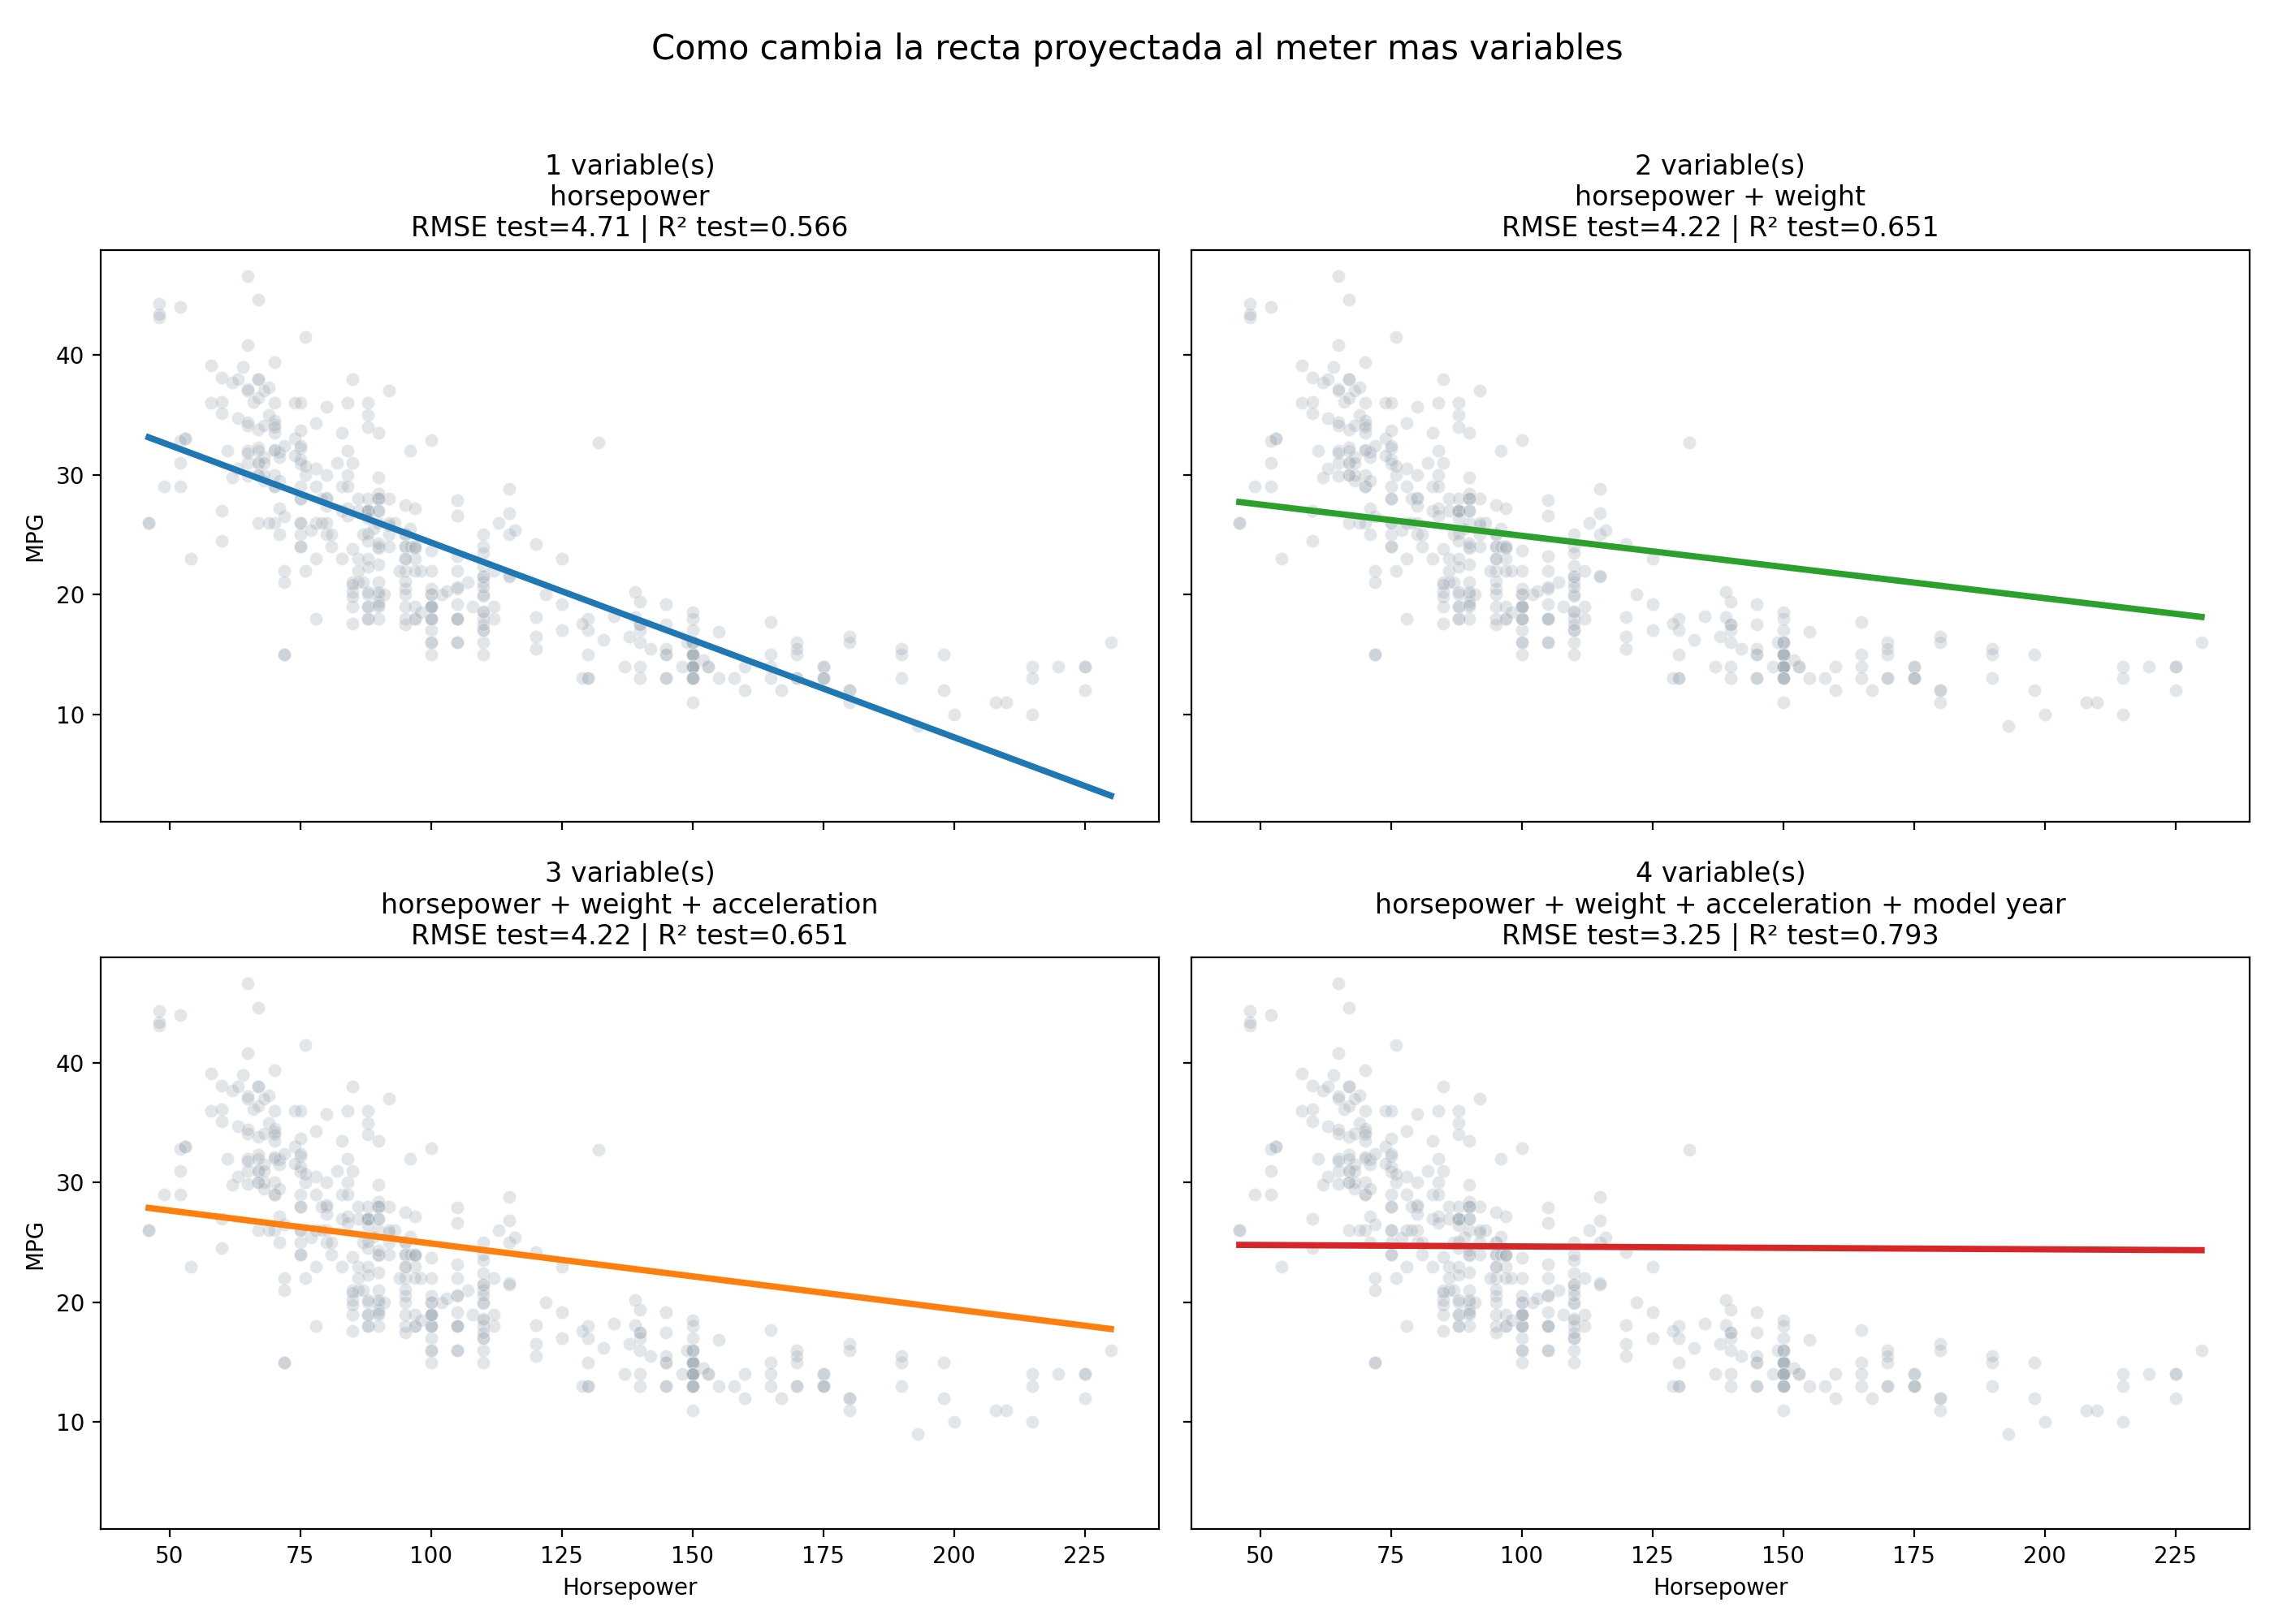

In [22]:
Image(filename=str(mpr.FIGURES_DIR / '18_progressive_feature_curves.png'))

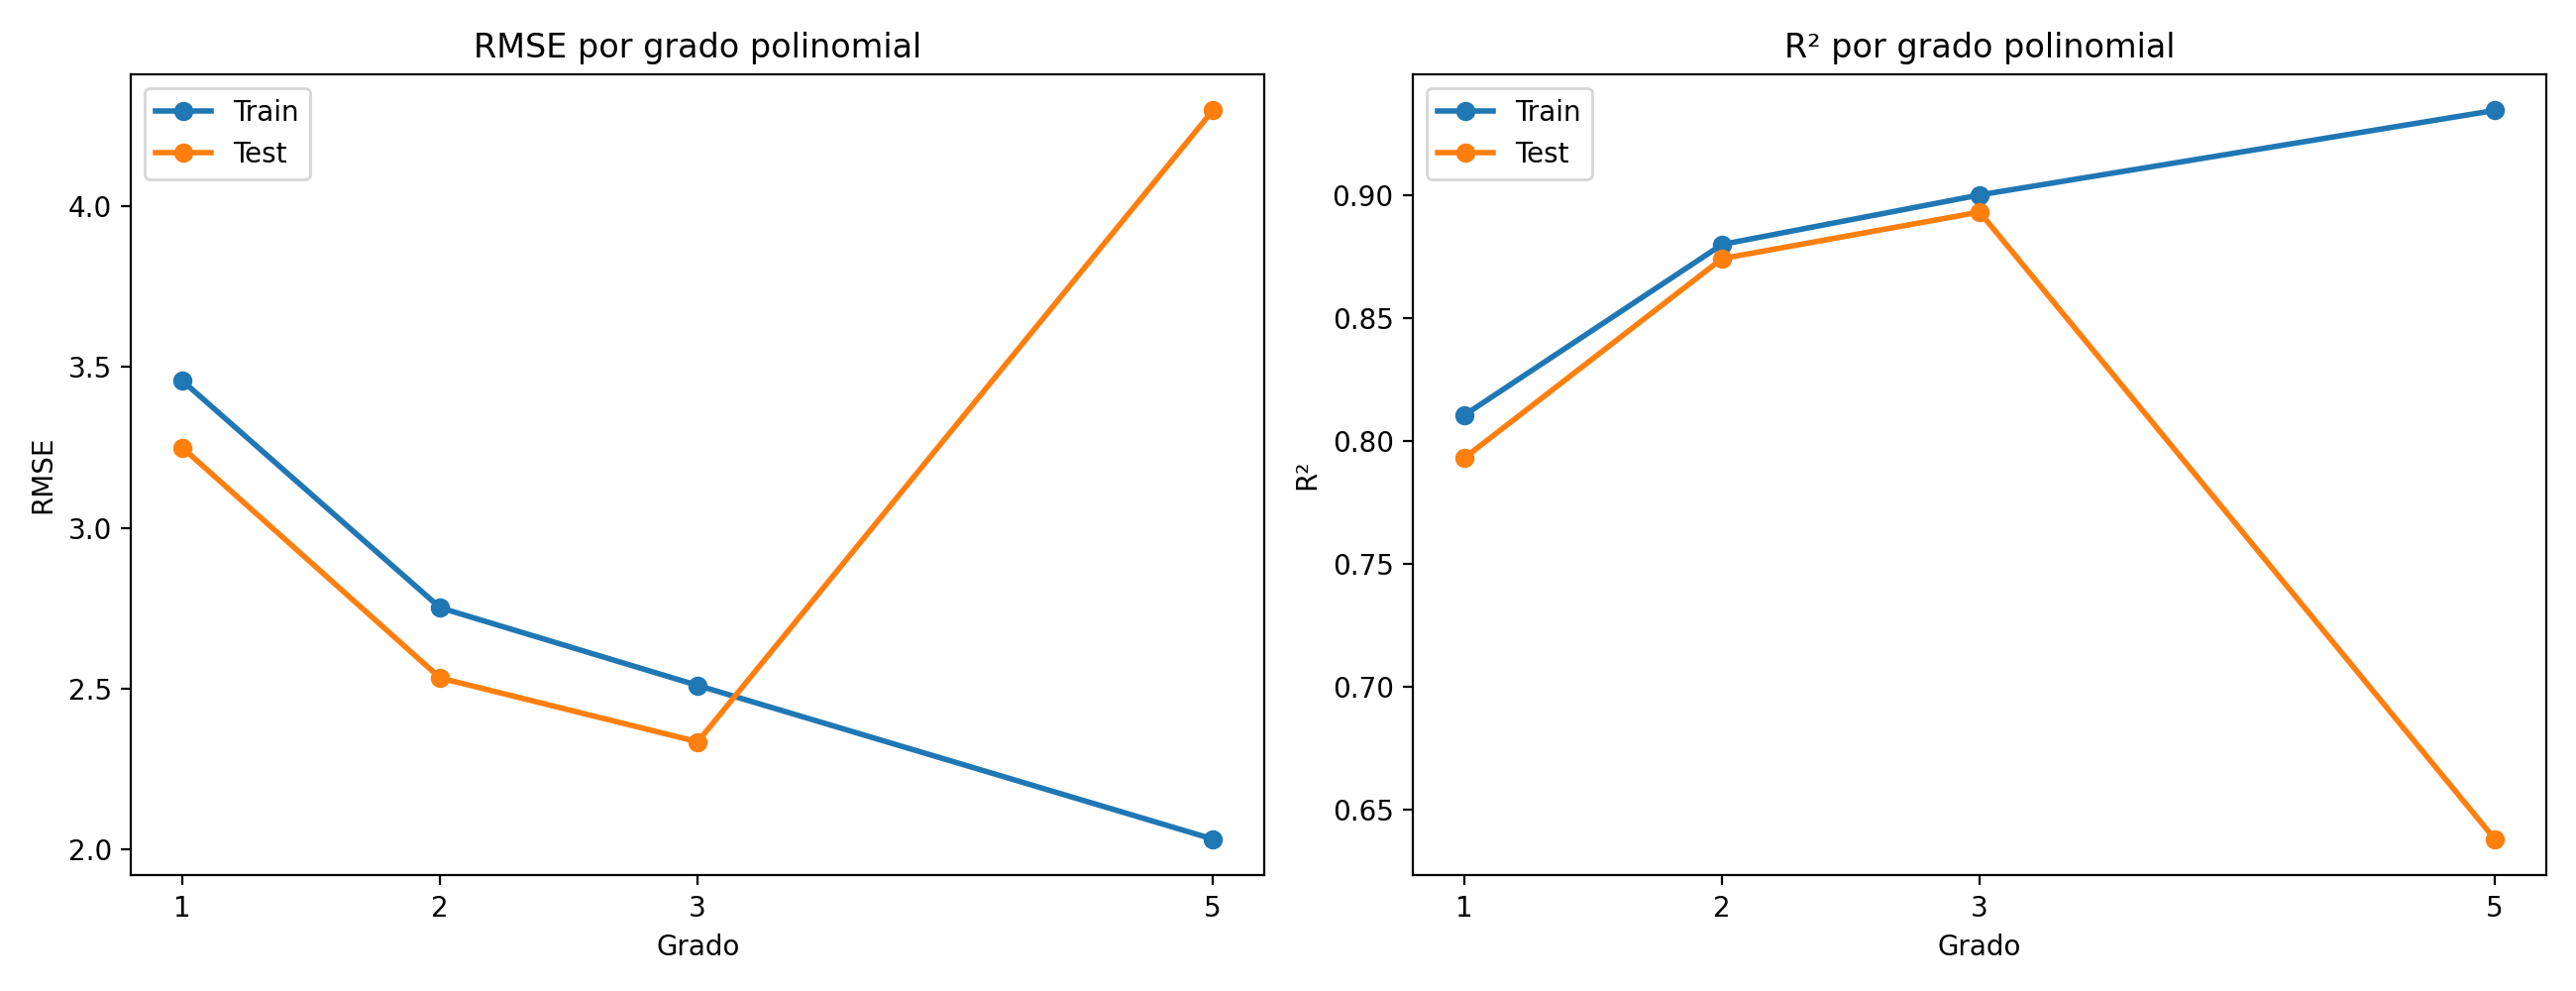

In [23]:
Image(filename=str(mpr.FIGURES_DIR / '12_multivariable_polynomial_metrics.png'))

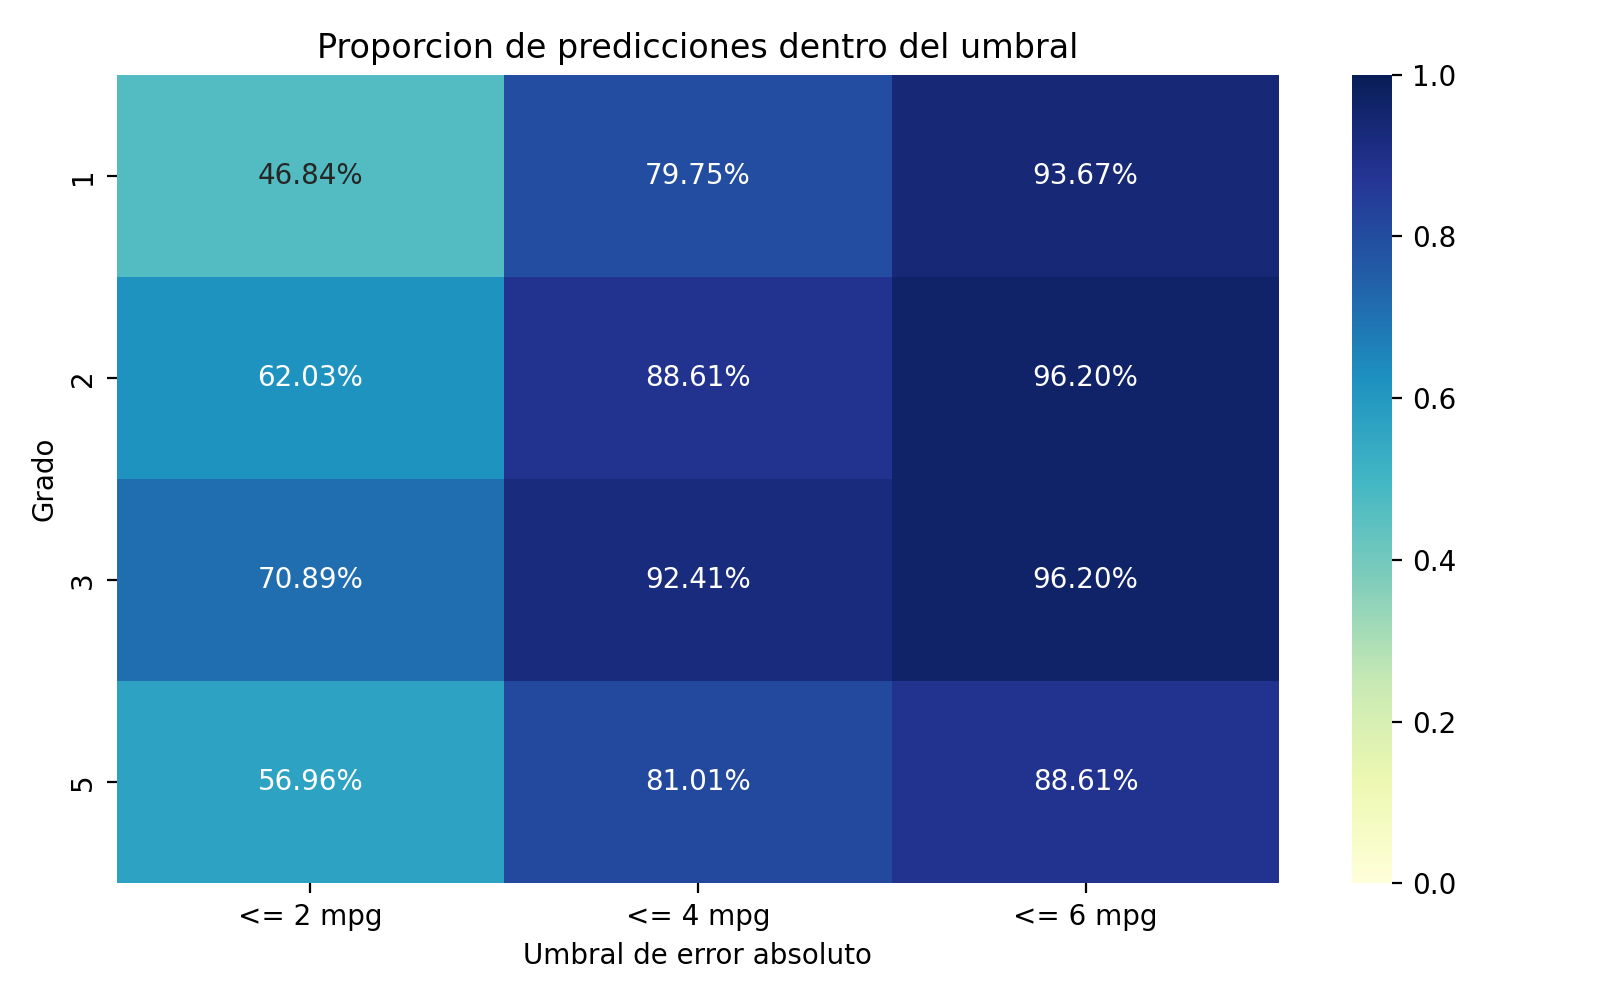

In [24]:
Image(filename=str(mpr.FIGURES_DIR / '13_multivariable_threshold_heatmap.png'))

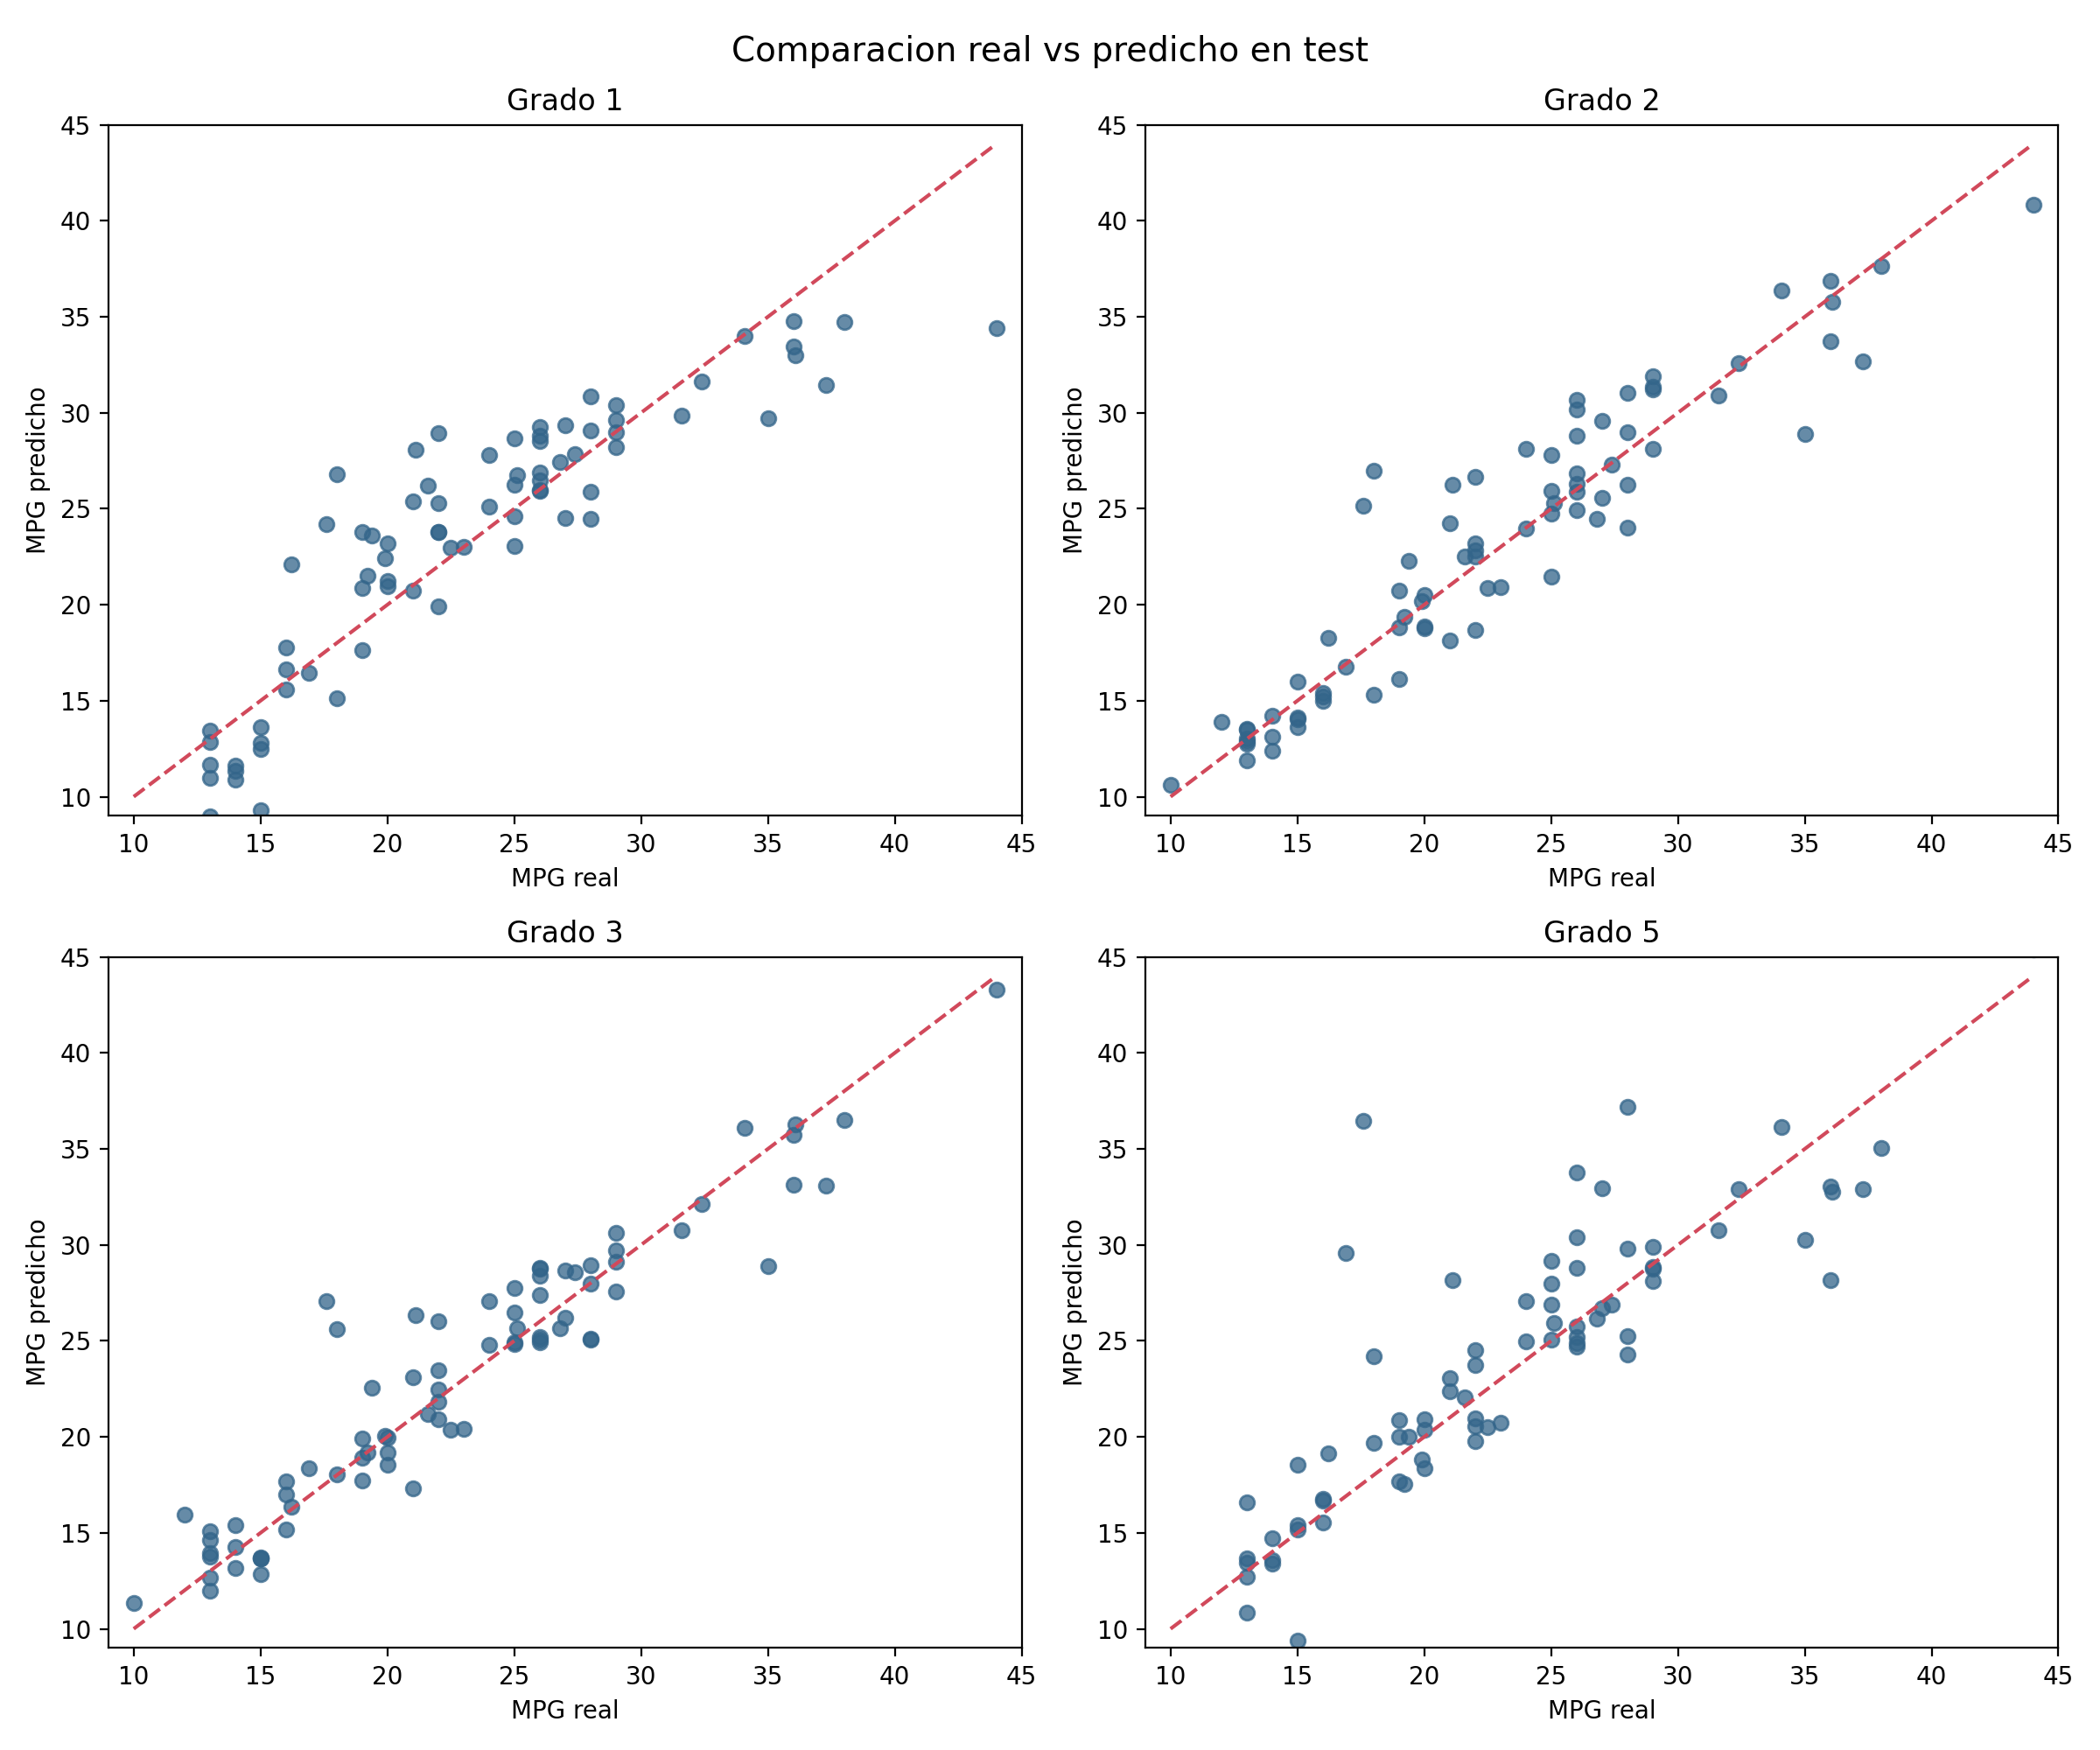

In [25]:
Image(filename=str(mpr.FIGURES_DIR / '14_multivariable_actual_vs_predicted.png'))

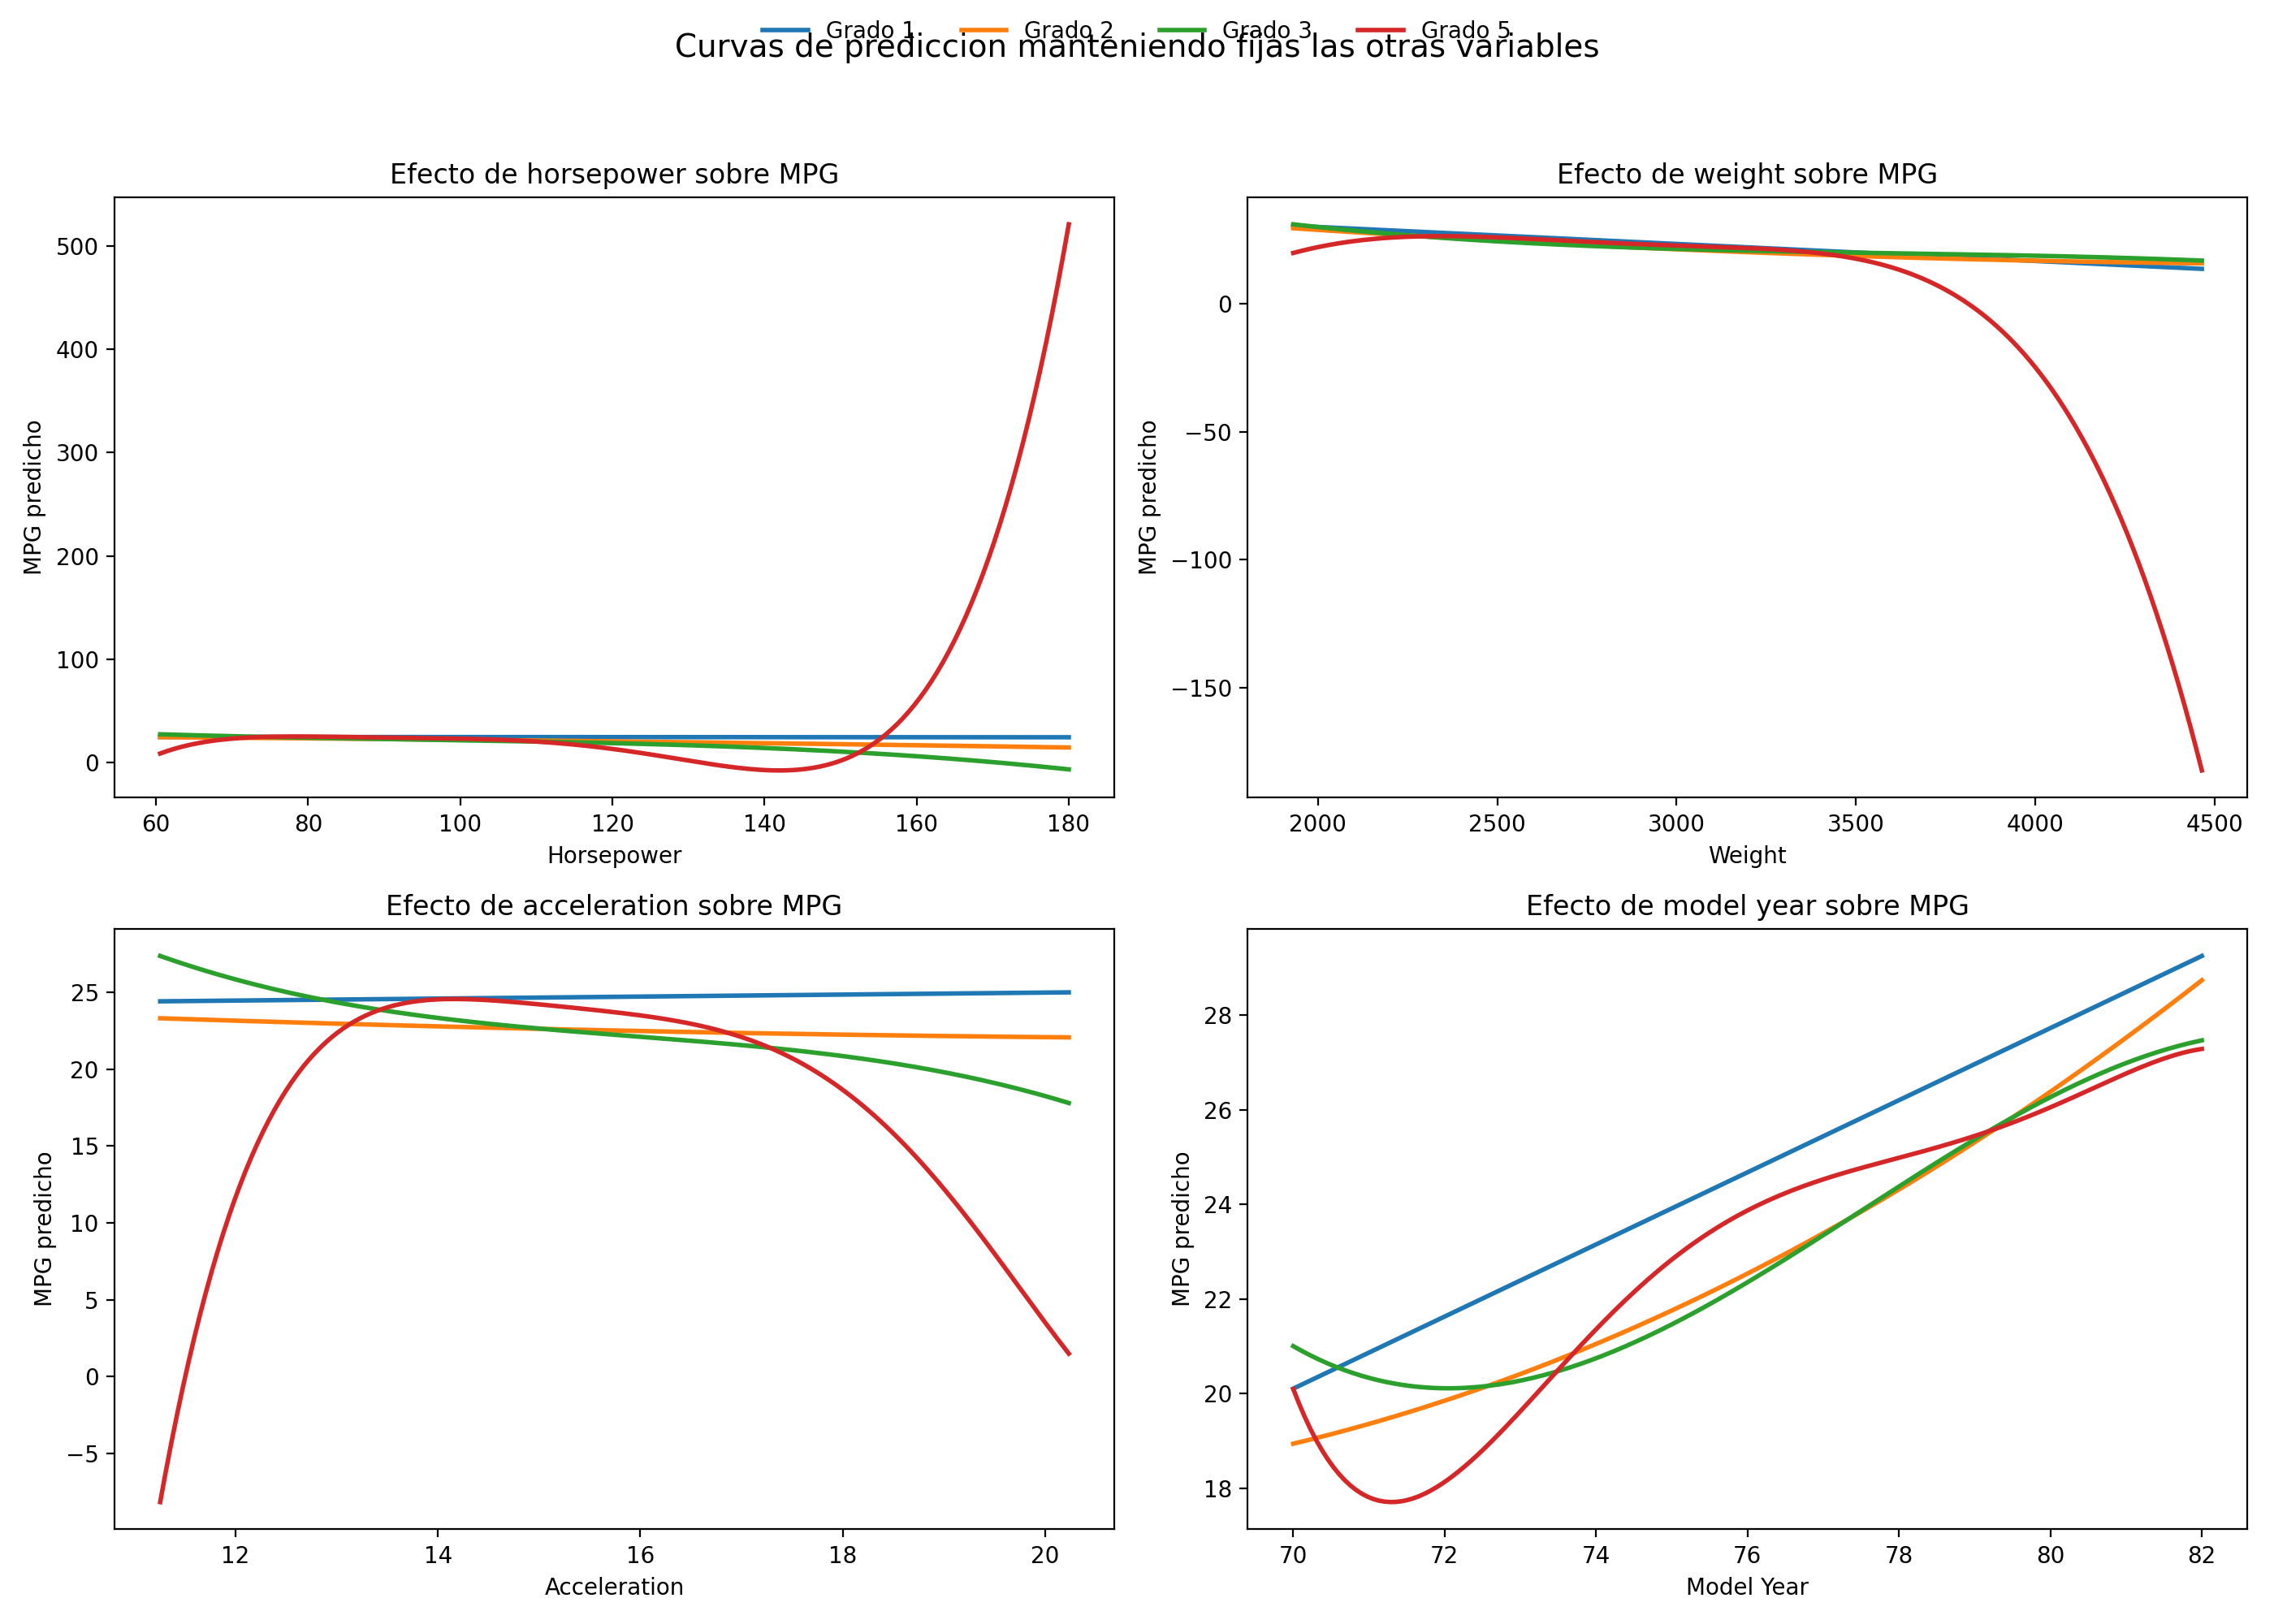

In [26]:
Image(filename=str(mpr.FIGURES_DIR / '15_multivariable_feature_effects.png'))

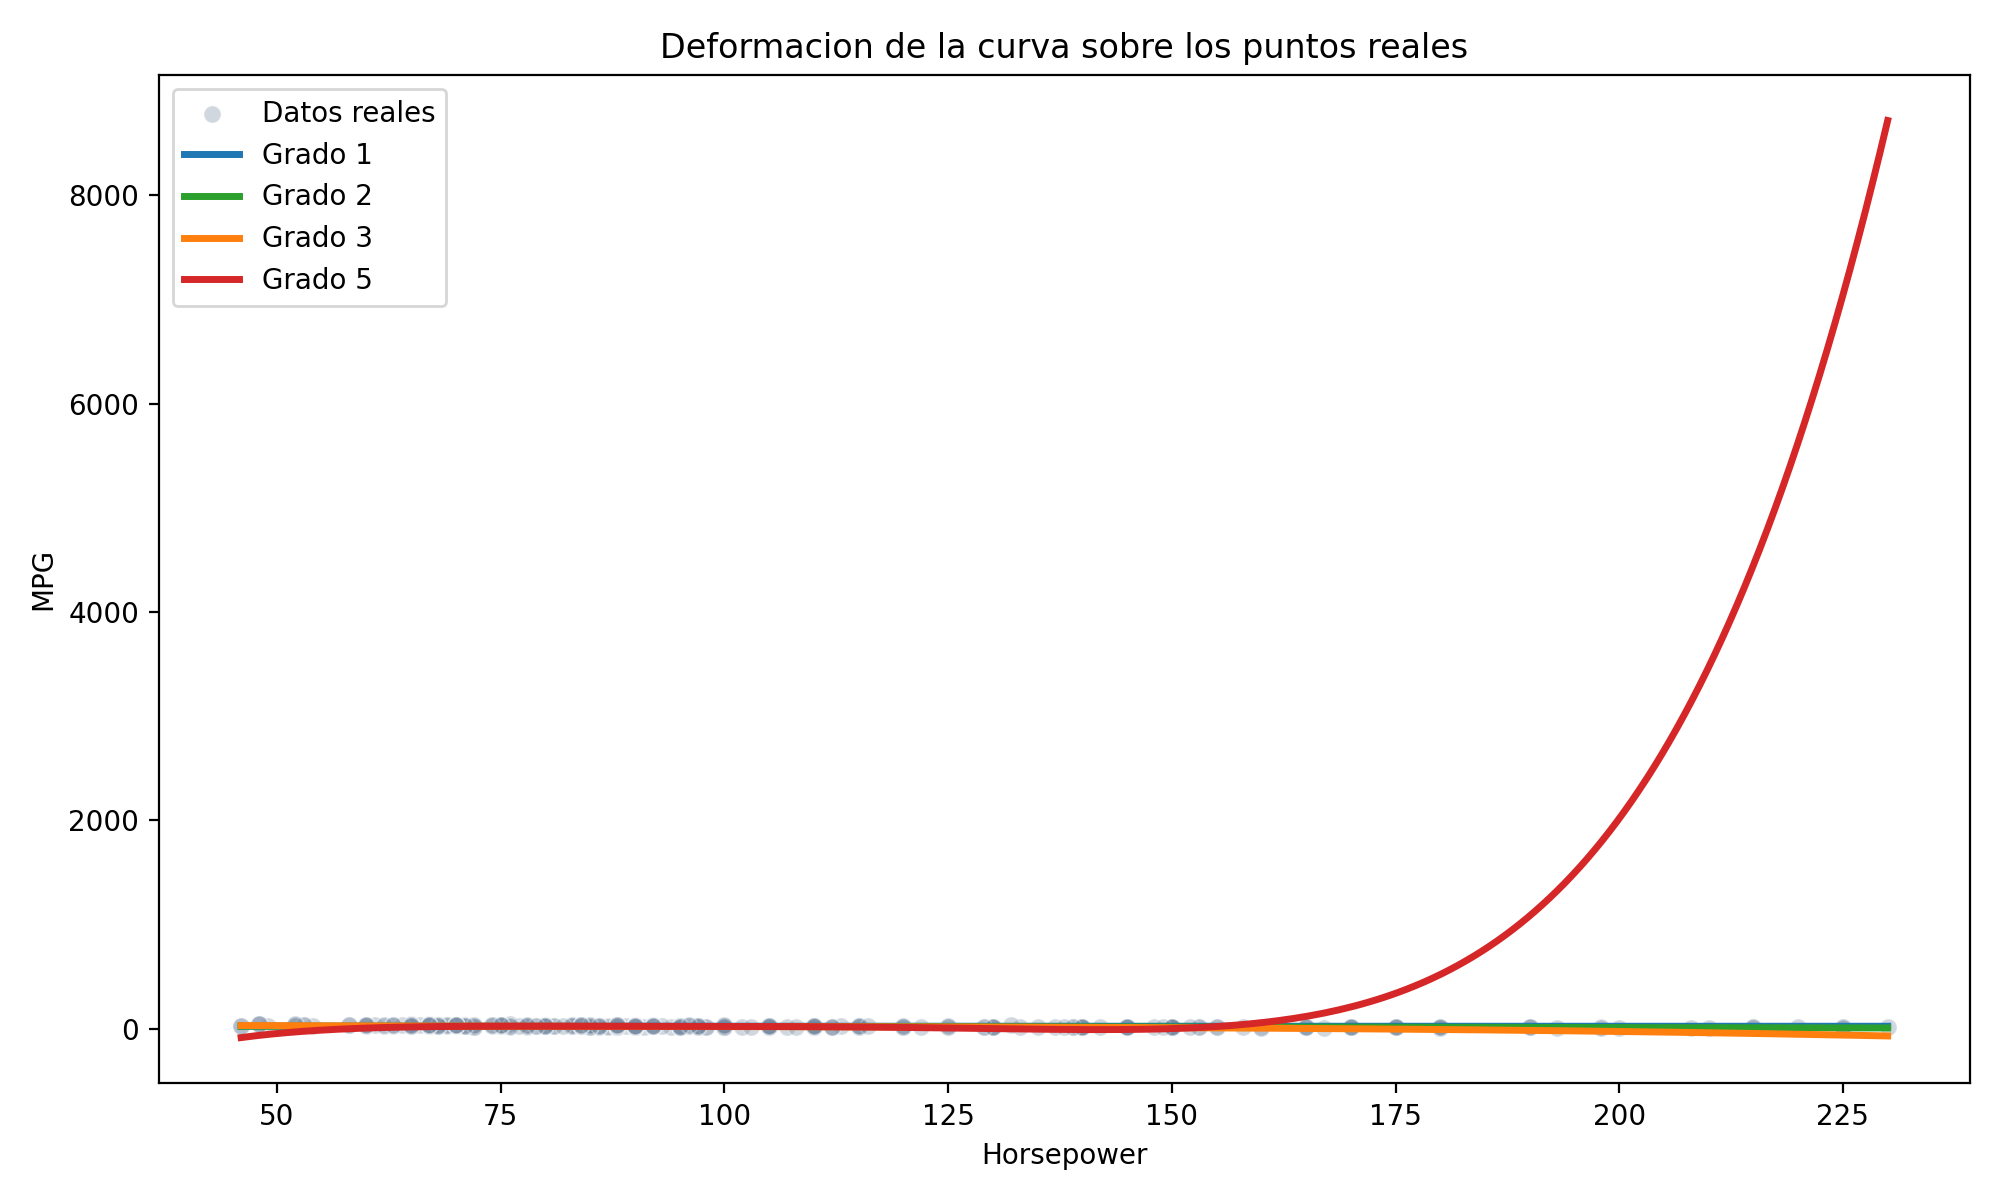

In [27]:
Image(filename=str(mpr.FIGURES_DIR / '16_curve_deformation_over_points.png'))

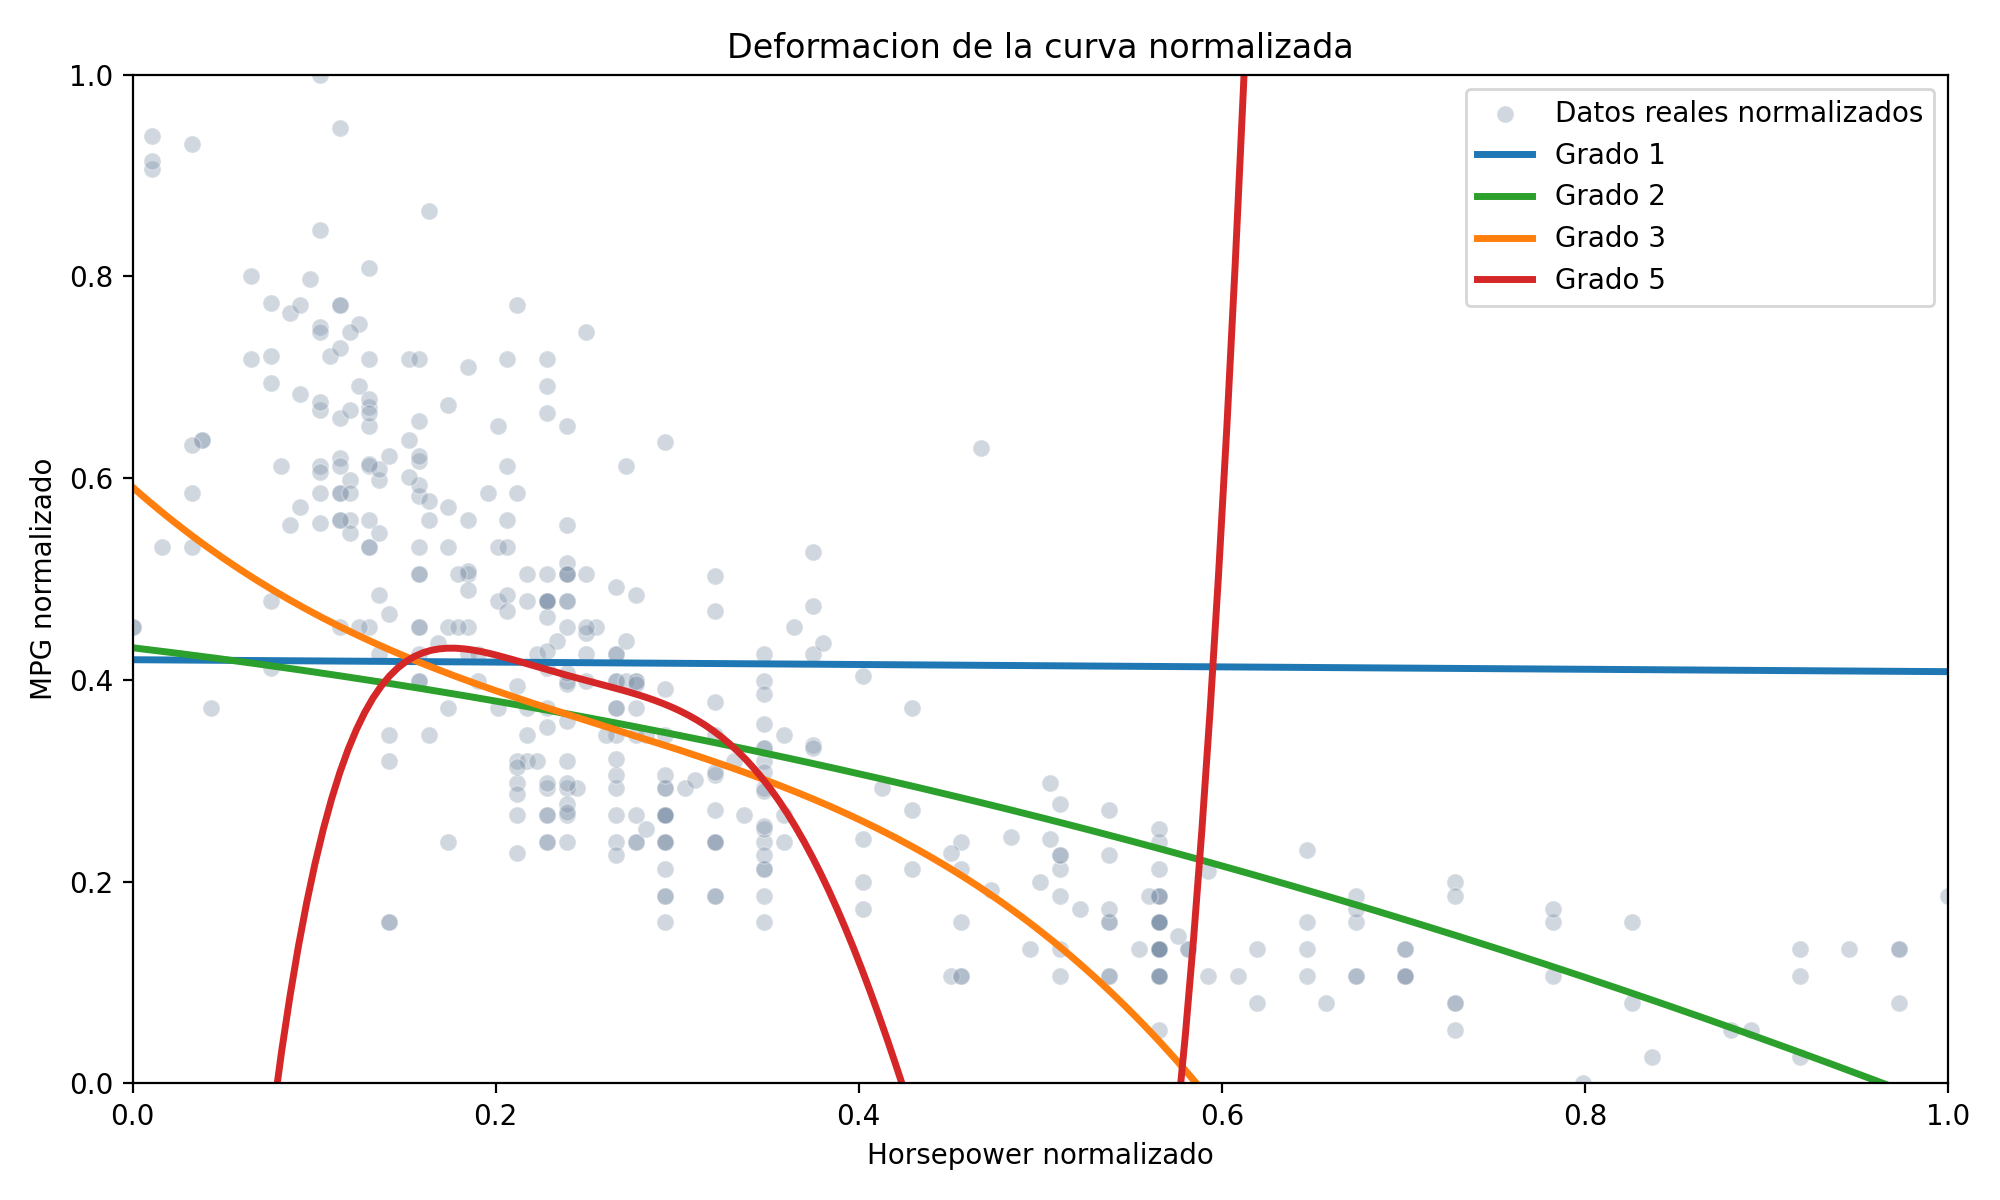

In [28]:
Image(filename=str(mpr.FIGURES_DIR / '17_normalized_curve_deformation.png'))

## Conclusion sugerida

- `Grado 1` sirve como baseline lineal, pero se queda corto frente a grados mayores.
- `Grado 2` mejora bastante el ajuste y la generalizacion.
- `Grado 3` ofrece la mejor combinacion entre flexibilidad y rendimiento en `test`.
- `Grado 5` mejora en `train`, pero empeora en `test`, lo que sugiere sobreajuste.

Esta lectura coincide con la recomendacion del PDF: no basta con que una curva se vea mas compleja; debe generalizar mejor.